# Exploring the database

After this tutorial you can load the observation tables, filter them by observing
conditions and target, choose a compact view of the columns, and use the Gaia and MOCA
columns to select stars by their properties.

```{tutorial-stamp}
```

You need the database tables from [Get the database](../getting-started/database.md).
The outputs on this page come from the v3.0.0 tables, so newer tables give larger
counts.
For a shorter introduction that finds one star, read
[Your first query](../getting-started/first-query.md) first.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from myst_nb import glue

from spherical.database.database_utils import resolve_mode_name
from spherical.database.paths import resolve_database_dir
from spherical.database.sphere_database import SphereDatabase, view

%config InlineBackend.figure_formats = ["png"]
plt.rcParams["figure.dpi"] = 100

## Load the tables

The database has one table of observations per instrument and mode, `ifs`, `ifs_sam`,
`irdis`, `irdis_polarimetry` and `irdis_sam`, where `sam` stands for sparse aperture
masking. `resolve_mode_name` turns the instrument and the two mode switches into the
file name. The table of files lists every raw file and lets the pipeline find the
files of an {term}`Observation sequence`.

In [ ]:
instrument = "ifs"               # "ifs" or "irdis"
polarimetry = False              # IRDIS only
sparse_aperture_masking = False

mode_name = resolve_mode_name(instrument, polarimetry, sparse_aperture_masking)
database_dir = resolve_database_dir(default=Path.home() / "data/sphere/database")

table_of_observations = Table.read(database_dir / f"table_of_observations_{mode_name}.fits")
table_of_files = Table.read(database_dir / f"table_of_files_{instrument}.csv")
database = SphereDatabase(table_of_observations, table_of_files, instrument=instrument)

n_observations = len(table_of_observations)
n_targets = len(np.unique(table_of_observations["MAIN_ID"]))
glue("n_observations", int(n_observations), display=False)
glue("n_targets", int(n_targets), display=False)
print(f"{n_observations} observation sequences of {n_targets} stars")

4733 observation sequences of 2320 stars


`resolve_database_dir` uses `$SPHERICAL_DATABASE_DIR` when it is set. The {term}`IFS`
table holds {glue:text}`n_observations` sequences of {glue:text}`n_targets` stars,
because many stars were observed at several epochs. Each row is one sequence, matched
to the nearest star in SIMBAD after correcting for proper motion. A large value in
`POS_DIFF`, the distance in arcseconds between the header position and the matched
star, points to a wrong match.

## Look at the observing conditions

The tables carry the conditions recorded in the file headers. `MEAN_FWHM` is the mean
seeing measured by the DIMM during the sequence, in arcseconds. It is a rough guide to
the image quality after adaptive optics, which also depends on the coherence time
(`MEAN_TAU`) and the brightness of the star.

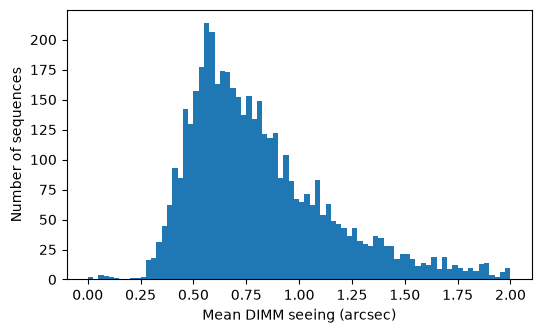

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(table_of_observations["MEAN_FWHM"], bins=np.linspace(0, 2, 81))
ax.set_xlabel("Mean DIMM seeing (arcsec)")
ax.set_ylabel("Number of sequences")
plt.show()

## Filter for usable observations

`database.filter` takes every column as a keyword. A single value tests equality, a
list tests membership, and a tuple `(op, value)` applies a comparison such as `">"`, a
membership test with `"in"` or `"not in"`, or a text search with `"contains"`. Criteria
combine with a logical AND, and a row with a missing value in a filtered column is
left out.

{term}`HCI_READY` marks sequences that have the centring and flux frames, consistent
exposure times and valid derotation data a reduction needs. `usable_only=True` is
stricter. It also requires {term}`Pupil tracking`, which angular differential imaging
needs, and a minimum science exposure time. The selection below keeps sequences in good
seeing, of bright stars within 300 pc, with more than 15 minutes on target.

In [ ]:
selected = database.filter(
    TOTAL_EXPTIME_SCI=(">", 15),
    MEAN_FWHM=("<", 1.2),
    FLUX_J=("<", 8),
    DISTANCE=("<", 300),
    usable_only=True,
)
glue("n_selected", len(selected), display=False)
print(f"{len(selected)} of {n_observations} sequences pass")

1300 of 4733 sequences pass


{glue:text}`n_selected` sequences pass. `view` keeps a subset of the columns. `"SHORT"`
shows the essentials, `"OBSLOG"` the details you quote in a paper, and `"NORMAL"`
drops the columns that are rarely needed. `database.show_in_browser()` opens the full
table as a searchable page in your browser.

In [ ]:
view(selected, "OBSLOG")[:10]

MAIN_ID,NIGHT_START,FILTER,WAFFLE_MODE,HCI_READY,DEROTATOR_MODE,PRIMARY_SCIENCE,DIT,NDIT,NCUBES,TOTAL_EXPTIME_SCI,TOTAL_EXPTIME_FLUX,ROTATION,MEAN_FWHM,MEAN_TAU,OBS_PROG_ID
bytes34,bytes10,bytes6,bool,bool,bytes5,bytes6,float64,int64,int64,float64,float64,float64,float64,float64,bytes14
* 3 Cen A,2019-02-21,OBS_H,False,True,PUPIL,CORO,64.0,3,16,51.2,0.133,71.901,0.497,0.012,1101.C-0258(B)
* 4 Eri,2024-11-10,OBS_H,False,True,PUPIL,CORO,64.0,1,16,17.067,0.067,1.436,0.65,0.005,114.2783.001
* 5 Vul,2016-04-13,OBS_YJ,False,True,PUPIL,CORO,32.0,1,73,38.933,0.167,14.854,0.515,0.008,097.C-1019(A)
* 5 Vul,2016-08-01,OBS_YJ,False,True,PUPIL,CORO,64.0,3,16,51.2,4.267,16.515,0.6,0.006,097.C-0750(A)
* 5 Vul,2017-07-14,OBS_YJ,False,True,PUPIL,CORO,64.0,1,24,25.6,0.2,8.54,0.614,0.004,099.C-0734(A)
* 6 Sex,2018-02-03,OBS_H,False,True,PUPIL,CORO,64.0,1,17,18.133,2.133,12.126,0.758,0.008,0100.C-0646(A)
* 9 Cet,2023-10-20,OBS_H,False,True,PUPIL,CORO,48.0,10,5,43.2,1.6,289.733,0.627,0.005,112.25N8.001
* 12 Psc,2023-07-13,OBS_YJ,False,True,PUPIL,CORO,8.0,17,28,63.467,1.333,55.474,0.672,0.004,111.24YA.001
* 12 Tri,2016-08-27,OBS_YJ,False,True,PUPIL,CORO,64.0,18,3,57.6,0.533,17.457,0.98,0.002,096.C-0388(A)


## Filter by target

`target_list` takes any name SIMBAD knows. Names already in the table, such as
`bet Pic` and `51 Eri` below, are found locally. Other names are resolved through
SIMBAD, which needs a network connection. A star reached through two names appears
once.

In [ ]:
targets = database.filter(
    target_list=["bet Pic", "51 Eri"],
    TOTAL_EXPTIME_SCI=(">", 15),
    usable_only=True,
)
print(f"{len(targets)} sequences")
view(targets, "SHORT")[:10]

26 sequences


MAIN_ID,NIGHT_START,FILTER,WAFFLE_MODE,HCI_READY,DEROTATOR_MODE,PRIMARY_SCIENCE,GAIA_TEFF,MOCA_AID,MOCA_BANYAN_PROB,MOCA_AGE_MYR,TOTAL_EXPTIME_SCI,ROTATION,MEAN_FWHM,OBS_PROG_ID
bytes34,bytes10,bytes6,bool,bool,bytes5,bytes6,float32,bytes9,float64,float64,float64,float64,float64,bytes14
* 51 Eri,2015-09-24,OBS_H,False,True,PUPIL,CORO,7250.0,BPMG,95.3067,26.0,68.267,43.216,0.754,095.C-0298(D)
* 51 Eri,2015-09-25,OBS_YJ,False,True,PUPIL,CORO,7250.0,BPMG,95.3067,26.0,72.533,43.141,0.987,095.C-0298(D)
* 51 Eri,2016-01-15,OBS_YJ,False,True,PUPIL,CORO,7250.0,BPMG,95.3067,26.0,68.267,40.226,1.886,096.C-0241(G)
* 51 Eri,2016-12-09,OBS_YJ,True,True,PUPIL,CENTER,7250.0,BPMG,95.3067,26.0,19.2,11.211,2.18,198.C-0209(C)
* 51 Eri,2016-12-11,OBS_YJ,True,True,PUPIL,CENTER,7250.0,BPMG,95.3067,26.0,57.6,25.339,1.957,198.C-0209(C)
* 51 Eri,2016-12-12,OBS_YJ,True,True,PUPIL,CENTER,7250.0,BPMG,95.3067,26.0,76.8,45.156,0.825,198.C-0209(C)
* 51 Eri,2017-09-27,OBS_H,True,True,PUPIL,CENTER,7250.0,BPMG,95.3067,26.0,82.133,52.079,0.467,198.C-0209(J)
* 51 Eri,2018-09-17,OBS_H,True,True,PUPIL,CENTER,7250.0,BPMG,95.3067,26.0,85.333,38.811,0.937,1100.C-0481(I)
* 51 Eri,2019-11-27,OBS_H,True,True,PUPIL,CENTER,7250.0,BPMG,95.3067,26.0,69.333,39.319,0.486,1104.C-0416(A)


## Plot a sample

The tables also describe the sample as a whole. This is the distance distribution of
the selection from above.

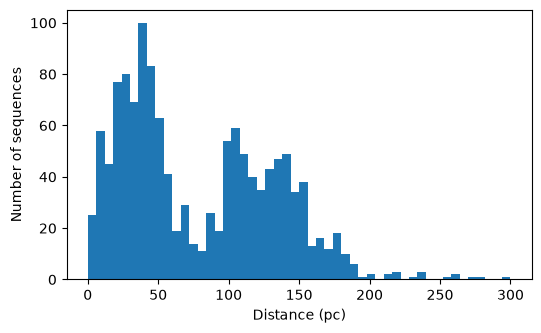

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(selected["DISTANCE"], bins=np.linspace(0, 300, 51))
ax.set_xlabel("Distance (pc)")
ax.set_ylabel("Number of sequences")
plt.show()

## Use the Gaia and MOCA columns

Each star is matched to Gaia DR3 and to MOCAdb, the Montreal Open Clusters and
Associations database. The `GAIA_TEFF`, `GAIA_LOGG`, `GAIA_MH` and `GAIA_AG` columns hold
the Gaia GSP-Phot temperature, surface gravity, metallicity and extinction, each with
`_LOWER` and `_UPPER` bounds. The `MOCA_` columns give the young association a star
belongs to and its adopted age. `MOCA_AID_SOURCE` says whether the membership comes
from the BANYAN Σ classifier (`banyan`) or the literature (`literature`).

Stars without a Gaia match have masked values in the Gaia columns, shown as `--`.
MOCA classifies stars outside any association as field stars, with `MOCA_AID` set to
`FIELD`, the association name `Field stars` and a placeholder age of 11.2 Gyr. Stars
MOCA does not know have empty MOCA columns.

In [ ]:
columns = ["MAIN_ID", "SP_TYPE", "GAIA_TEFF", "GAIA_LOGG",
           "MOCA_ASSOCIATION_NAME", "MOCA_AGE_MYR", "MOCA_AID_SOURCE"]
table_of_observations[columns][:10]

MAIN_ID,SP_TYPE,GAIA_TEFF,GAIA_LOGG,MOCA_ASSOCIATION_NAME,MOCA_AGE_MYR,MOCA_AID_SOURCE
bytes34,bytes21,float32,float32,bytes49,float64,bytes6
* 3 Cen A,B5III,14637.0,4.14,Sco-Cen subregion 20 from Ratzenboeck et al. 2023,15.2,banyan
* 4 Eri,A5IV/V,7622.0,3.95,Field stars,11200.0,banyan
* 4 Eri,A5IV/V,7622.0,3.95,Field stars,11200.0,banyan
* 4 Eri,A5IV/V,7622.0,3.95,Field stars,11200.0,banyan
* 4 Sgr,A0,--,--,Field stars,11200.0,banyan
* 5 Vul,A0V,9865.0,4.1,Field stars,11200.0,banyan
* 5 Vul,A0V,9865.0,4.1,Field stars,11200.0,banyan
* 5 Vul,A0V,9865.0,4.1,Field stars,11200.0,banyan
* 6 Sex,A4V,8074.0,4.2,Ursa Major corona,414.0,banyan


An age cut on the MOCA columns selects members of young associations, the stars where
direct imaging finds planets most often. Field stars drop out through their placeholder
age, and stars without a MOCA match through their missing age.

In [ ]:
from collections import Counter

association = np.char.strip(np.asarray(table_of_observations["MOCA_ASSOCIATION_NAME"]).astype(str))
age = np.ma.filled(table_of_observations["MOCA_AGE_MYR"].astype(float), np.nan)
young = np.isfinite(age) & (age < 150)

print(f"{young.sum()} sequences of {len(np.unique(table_of_observations['MAIN_ID'][young]))} "
      "stars in associations younger than 150 Myr")
for name, count in Counter(association[young]).most_common(8):
    print(f"{count:5d}  {name}")

2160 sequences of 949 stars in associations younger than 150 Myr
  162  beta Pictoris moving group
   96  AB Doradus moving group
   95  Columba association
   78  Sco-Cen subregion 20 from Ratzenboeck et al. 2023
   65  NGC 3603 open cluster
   64  Lower Centaurus Crux OB association
   61  Argus association
   55  Orion-Perseus complex


## Next

[Your first query](../getting-started/first-query.md) follows one star, 51 Eri, through
the table, and [The observation database](../concepts/database.md) explains how the
tables are built and what the quality flags mean.